# Ноутбук 05: Fine-tuning на русском датасете отзывов

**Задача:** дообучить модель на классификацию русских рецензий по тональности.

- **Датасет:** `blinoff/kinopoisk` (`Bad`, `Neutral`, `Good`)
- **Модель:** `cointegrated/rubert-tiny2`
- **Классы после маппинга:** `NEGATIVE`, `NEUTRAL`, `POSITIVE`

Что добавлено:
- полностью заменены и датасет, и язык;
- выбрана другая модель под русский;
- сделана фильтрация данных;
- собрана сбалансированная выборка;
- выполнен train/test split;
- есть baseline до обучения и оценка после обучения;
- добавлена confusion matrix;
- есть проверка на новых примерах


In [1]:
import os
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline as hf_pipeline,
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from huggingface_hub.utils import disable_progress_bars

disable_progress_bars()
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print('torch:', torch.__version__)
print('GPU доступен:', torch.cuda.is_available())


c:\anacon\envs\nlp_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.9.1+cu126
GPU доступен: True


## Шаг 1: Загрузка и подготовка датасета

In [2]:
label_map_src_to_id = {'Bad': 0, 'Neutral': 1, 'Good': 2}
id2label = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}
label2id = {v: k for k, v in id2label.items()}

raw_dataset = load_dataset('blinoff/kinopoisk', split='train[:14000]')

filtered_dataset = raw_dataset.filter(
    lambda x: isinstance(x['content'], str) and len(x['content'].strip()) > 60 and x['grade3'] in label_map_src_to_id
)

print('Размер исходного среза:', len(raw_dataset))
print('После фильтрации:', len(filtered_dataset))
print('Поля:', filtered_dataset.column_names)


Размер исходного среза: 14000
После фильтрации: 14000
Поля: ['part', 'movie_name', 'review_id', 'author', 'date', 'title', 'grade3', 'grade10', 'content']


In [3]:
def get_one_example(ds, grade3_label):
    item = ds.filter(lambda x: x['grade3'] == grade3_label).select(range(1))[0]
    return item

example_bad = get_one_example(filtered_dataset, 'Bad')
example_neu = get_one_example(filtered_dataset, 'Neutral')
example_good = get_one_example(filtered_dataset, 'Good')

print('=== NEGATIVE (Bad) ===')
print(example_bad['content'][:400], '...')
print()
print('=== NEUTRAL (Neutral) ===')
print(example_neu['content'][:400], '...')
print()
print('=== POSITIVE (Good) ===')
print(example_good['content'][:400], '...')


=== NEGATIVE (Bad) ===

Как же уныло… Я вынужден констатировать, что славная студия Дисней утратила моё доверие и попала в чёрный список студий, новые мультфильмы которых теперь я смотреть не буду. Признаться, в списке до этого были лишь ДримВоркс, но если учесть, что для меня в анимации существует только три крупных рыбы — Дисней, ДримВоркс и Пиксар, то надежда остаётся только на последних. Те, слава Богу, в последние  ...

=== NEUTRAL (Neutral) ===

- как пела Земфира, скорее всего, по совершенно другому поводу.

А вот и еще один «фильм с Челентаной», широко известный и всенародно любимый на территории бывшего СССР. По мне, так он получше более позднего «Укрощения строптивого» — в нем поменьше безыскусных домогательств и хамства.

Жанр фильма — «сентиментальная гангстерская байка», изложенная в виде комедии. Потенциал у жанра небольшой, но е ...

=== POSITIVE (Good) ===

"Блеф» — одна из моих самых любимых комедий.

Этот фильм я наверно смотрел раз сто, нет я конечно блефую, я видел 

,class_src,class_model,count,ratio
2,Bad,NEGATIVE,646,0.046143
1,Neutral,NEUTRAL,1487,0.106214
0,Good,POSITIVE,11867,0.847643


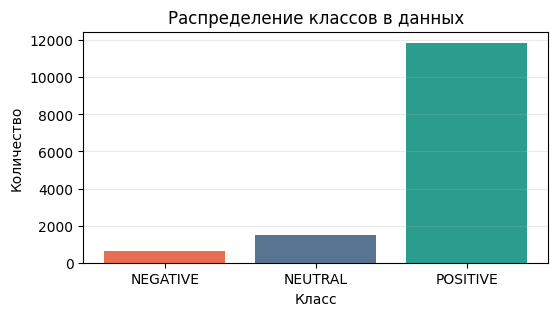

In [4]:
raw_counts = Counter(filtered_dataset['grade3'])
class_stats = pd.DataFrame(
    [
        {'class_src': k, 'class_model': id2label[label_map_src_to_id[k]], 'count': v, 'ratio': v / len(filtered_dataset)}
        for k, v in raw_counts.items()
    ]
).sort_values('class_model')

display(class_stats)

plt.figure(figsize=(6, 3))
plt.bar(class_stats['class_model'], class_stats['count'], color=['#e76f51', '#577590', '#2a9d8f'])
plt.title('Распределение классов в данных')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.25)
plt.show()


In [5]:
# Формируем сбалансированную выборку для обучения
per_class = 240
class_subsets = []

for src_label in ['Bad', 'Neutral', 'Good']:
    subset = filtered_dataset.filter(lambda x, y=src_label: x['grade3'] == y).shuffle(seed=SEED)
    take_n = min(per_class, len(subset))
    class_subsets.append(subset.select(range(take_n)))

balanced_dataset = concatenate_datasets(class_subsets).shuffle(seed=SEED)
split = balanced_dataset.train_test_split(test_size=0.2, seed=SEED)

train_data = split['train'].map(lambda x: {'label': label_map_src_to_id[x['grade3']], 'text': x['content']})
test_data = split['test'].map(lambda x: {'label': label_map_src_to_id[x['grade3']], 'text': x['content']})

train_data = train_data.remove_columns([c for c in train_data.column_names if c not in ['text', 'label']])
test_data = test_data.remove_columns([c for c in test_data.column_names if c not in ['text', 'label']])

print('Train:', len(train_data), 'примеров')
print('Test: ', len(test_data), 'примеров')
print('Распределение train:', Counter([id2label[x] for x in train_data['label']]))
print('Распределение test: ', Counter([id2label[x] for x in test_data['label']]))


Train: 576 примеров
Test:  144 примеров
Распределение train: Counter({'POSITIVE': 196, 'NEUTRAL': 194, 'NEGATIVE': 186})
Распределение test:  Counter({'NEGATIVE': 54, 'NEUTRAL': 46, 'POSITIVE': 44})


## Шаг 2: Токенизация

In [6]:
MODEL_NAME = 'cointegrated/rubert-tiny2'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample = train_data[0]
encoded = tokenizer(sample['text'], truncation=True, max_length=256)

print('Модель токенизатора:', MODEL_NAME)
print('Пример текста:', sample['text'][:160], '...')
print('Метка:', id2label[sample['label']])
print('Количество токенов:', len(encoded['input_ids']))
print('Первые 15 token ids:', encoded['input_ids'][:15])


Модель токенизатора: cointegrated/rubert-tiny2
Пример текста: 
Думаю, все заметили, что от любимых рассказов Артура Конан Дойля остались одни лищь имена главных персонажей. А жаль. 

Если воспринимать данный фильм как нечт ...
Метка: NEUTRAL
Количество токенов: 256
Первые 15 token ids: [2, 33730, 16, 2749, 35366, 16, 1046, 733, 40103, 41204, 53715, 53849, 679, 3130, 21052]


In [7]:
def tokenize_batch(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=256,
        padding=False,
    )

tokenized_train = train_data.map(tokenize_batch, batched=True)
tokenized_test = test_data.map(tokenize_batch, batched=True)

print('Токенизация завершена.')
print('Колонки tokenized_train:', tokenized_train.column_names)


Токенизация завершена.
Колонки tokenized_train: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask']


## Шаг 3: Модель и Trainer

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Всего параметров: {total_params:,} ({total_params/1e6:.1f}M)')
print(f'Обучаемых:        {trainable_params:,} ({trainable_params/1e6:.1f}M)')


Loading weights: 100%|██████████| 55/55 [00:00<00:00, 13756.74it/s]
BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were 

Всего параметров: 29,194,707 (29.2M)
Обучаемых:        29,194,707 (29.2M)


In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }


In [10]:
training_args = TrainingArguments(
    output_dir='./results_ru_finetune',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=5e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='no',
    logging_strategy='steps',
    logging_steps=30,
    report_to='none',
    seed=SEED,
    disable_tqdm=True,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print('Trainer готов.')
print('Эпох:', training_args.num_train_epochs)
print('Батч train:', training_args.per_device_train_batch_size)


Trainer готов.
Эпох: 3
Батч train: 16


## Шаг 4: Оценка до обучения (baseline)

In [12]:
baseline_metrics = trainer.evaluate()

print('Baseline:')
print(f"  Accuracy: {baseline_metrics['eval_accuracy']:.1%}")
print(f"  F1 macro: {baseline_metrics['eval_f1_macro']:.3f}")


{'eval_loss': '1.1', 'eval_model_preparation_time': '0.001', 'eval_accuracy': '0.3125', 'eval_f1_macro': '0.2687', 'eval_runtime': '0.6938', 'eval_samples_per_second': '207.6', 'eval_steps_per_second': '7.207', 'epoch': 0}
Baseline:
  Accuracy: 31.2%
  F1 macro: 0.269


## Шаг 5: Fine-tuning

In [13]:
train_result = trainer.train()

print('Обучение завершено.')
print(f"Время: {train_result.metrics['train_runtime']:.1f} сек")
print(f"Train loss: {train_result.metrics['train_loss']:.3f}")


{'loss': '1.097', 'grad_norm': '1.061', 'learning_rate': '3.657e-05', 'epoch': '0.8333'}
{'eval_loss': '1.086', 'eval_model_preparation_time': '0.001', 'eval_accuracy': '0.3819', 'eval_f1_macro': '0.2917', 'eval_runtime': '0.261', 'eval_samples_per_second': '551.7', 'eval_steps_per_second': '19.16', 'epoch': '1'}
{'loss': '1.064', 'grad_norm': '1.341', 'learning_rate': '2.269e-05', 'epoch': '1.667'}
{'eval_loss': '1.061', 'eval_model_preparation_time': '0.001', 'eval_accuracy': '0.5139', 'eval_f1_macro': '0.445', 'eval_runtime': '0.2641', 'eval_samples_per_second': '545.2', 'eval_steps_per_second': '18.93', 'epoch': '2'}
{'loss': '1.032', 'grad_norm': '2.591', 'learning_rate': '8.796e-06', 'epoch': '2.5'}
{'eval_loss': '1.054', 'eval_model_preparation_time': '0.001', 'eval_accuracy': '0.4514', 'eval_f1_macro': '0.4166', 'eval_runtime': '0.262', 'eval_samples_per_second': '549.6', 'eval_steps_per_second': '19.09', 'epoch': '3'}
{'train_runtime': '11.39', 'train_samples_per_second': '151

## Шаг 6: Оценка после обучения

In [14]:
final_metrics = trainer.evaluate()

print('После fine-tuning:')
print(f"  Accuracy: {final_metrics['eval_accuracy']:.1%}")
print(f"  F1 macro: {final_metrics['eval_f1_macro']:.3f}")
print()
print('Сравнение:')
print(f"  Accuracy: {baseline_metrics['eval_accuracy']:.1%} -> {final_metrics['eval_accuracy']:.1%}")
print(f"  F1 macro: {baseline_metrics['eval_f1_macro']:.3f} -> {final_metrics['eval_f1_macro']:.3f}")


{'eval_loss': '1.054', 'eval_model_preparation_time': '0.001', 'eval_accuracy': '0.4514', 'eval_f1_macro': '0.4166', 'eval_runtime': '0.2672', 'eval_samples_per_second': '538.9', 'eval_steps_per_second': '18.71', 'epoch': '3'}
После fine-tuning:
  Accuracy: 45.1%
  F1 macro: 0.417

Сравнение:
  Accuracy: 31.2% -> 45.1%
  F1 macro: 0.269 -> 0.417


,PRED_NEGATIVE,PRED_NEUTRAL,PRED_POSITIVE
TRUE_NEGATIVE,32,11,11
TRUE_NEUTRAL,19,6,21
TRUE_POSITIVE,11,6,27


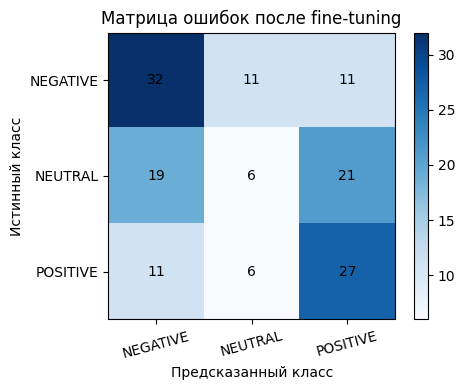

Ошибок на test: 79 из 144
--- Ошибка 1 ---
Истинный класс: NEUTRAL
Предсказанный:  POSITIVE
Текст: 
Поведанная в «Догвиле» история, относимая к периоду Великой Депрессии и рассказанная, как гласит подзаголовок, «в девяти действиях с одним прологом», феноменальна, исключительна, если не сказать — сенсационна. 

Режиссёр-сценарист обманывает (точнее, опрокиды ...

--- Ошибка 2 ---
Истинный класс: POSITIVE
Предсказанный:  NEGATIVE
Текст: 
Только что посмотрела этот фильм. Слезы душат до сих пор, еле вижу клавиши. 

И пусть говорят, что американцы притянули за уши очередную слезоточивую драму, пусть говорят.

Я хочу отметить одно, если фильм смог вызвать такую бурю эмоций, закончился запас плат ...

--- Ошибка 3 ---
Истинный класс: NEUTRAL
Предсказанный:  NEGATIVE
Текст: 
Выше поставить рука не поднимается, ниже — уважение к студии «Дисней» не позволяет. 

Я ждала этот мультфильм как экранизацию сказки, мне думалось, что я увижу что-то доброе, по-настоящему волшебное в духе «Золушки». 

Чт

In [15]:
pred_output = trainer.predict(tokenized_test)
pred_labels = np.argmax(pred_output.predictions, axis=-1)
true_labels = pred_output.label_ids

labels_order = [0, 1, 2]
cm = confusion_matrix(true_labels, pred_labels, labels=labels_order)
cm_df = pd.DataFrame(cm, index=[f'TRUE_{id2label[i]}' for i in labels_order], columns=[f'PRED_{id2label[i]}' for i in labels_order])

display(cm_df)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Матрица ошибок после fine-tuning')
plt.xticks(range(3), [id2label[i] for i in labels_order], rotation=15)
plt.yticks(range(3), [id2label[i] for i in labels_order])
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

errors = [
    {
        'text': test_data[i]['text'],
        'true': id2label[int(true_labels[i])],
        'pred': id2label[int(pred_labels[i])],
    }
    for i in range(len(test_data))
    if int(pred_labels[i]) != int(true_labels[i])
]

print(f'Ошибок на test: {len(errors)} из {len(test_data)}')
for i, err in enumerate(errors[:3], 1):
    print(f'--- Ошибка {i} ---')
    print('Истинный класс:', err['true'])
    print('Предсказанный: ', err['pred'])
    print('Текст:', err['text'][:260], '...')
    print()


## Шаг 7: Проверка на новых русских примерах

In [16]:
classifier = hf_pipeline(
    task='text-classification',
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

my_texts = [
    'Фильм оказался удивительно глубоким и трогательным, рекомендую к просмотру.',
    'Снято дешево, актеры переигрывают, смотреть невозможно.',
    'Есть интересные идеи, но реализация неровная: местами скучно, местами увлекательно.',
]

results = classifier(my_texts, truncation=True, max_length=256)
for text, result in zip(my_texts, results):
    print(f"{result['label']:9s} ({result['score']:.1%}): {text}")


NEUTRAL   (40.6%): Фильм оказался удивительно глубоким и трогательным, рекомендую к просмотру.
NEUTRAL   (38.7%): Снято дешево, актеры переигрывают, смотреть невозможно.
NEUTRAL   (37.7%): Есть интересные идеи, но реализация неровная: местами скучно, местами увлекательно.


In [17]:
save_dir = './my_ru_sentiment_classifier'
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print('Модель сохранена в', save_dir)
print("Для загрузки: pipeline('text-classification', model='./my_ru_sentiment_classifier')")


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.02it/s]

Модель сохранена в ./my_ru_sentiment_classifier
Для загрузки: pipeline('text-classification', model='./my_ru_sentiment_classifier')
